In [1]:
%load_ext autoreload
%autoreload 2

import warnings

warnings.filterwarnings("ignore")

# Embedding Refinement

This page illustrates how to refine embeddings.

## Basic Parameters

All parameters that control the embedding space are attributes of the `GlassBoxUMAP` that can be set either during creation of the object or afterwards.

In [2]:
from glass_box_umap import GlassBoxUMAP

# Set the number of neighbors to 25 (during construction)
reducer = GlassBoxUMAP(n_neighbors=25)

# Actually, let's use 20 (post-hoc)
reducer.n_neighbors = 20

For the full suite of options, see the API below.

:::{admonition} GlassBoxUMAP API
:class: api, dropdown

From the {class}`API docs <glass_box_umap.GlassBoxUMAP>`:

```{eval-rst}
.. autoclass:: glass_box_umap.GlassBoxUMAP
    :noindex:
```
:::

:::{note}
All the default parameters match `umap-learn` defaults (as of umap-learn `v0.5.9.post2`).
:::

:::{note}
If you want to use a parameter that's supported in standard UMAP but absent in Glass Box UMAP, please [file a feature request](https://github.com/Arcadia-Science/glass-box-umap/issues/new/choose).
:::

## Parameters unique to Glass Box UMAP

In addition to common UMAP parameters, Glass Box UMAP introduces unique parameters.

| Name | Parameter | Description |
| --- | --- | --- |
| Epochs | `epochs` | Number of passes over the training data. |
| Batch size | `batch_size` | Number of samples per training step. |
| Encoder layers[^encoder_params] | `encoder_kwargs["n_hidden_layers"]` | Number of hidden layers in the encoder MLP. |
| Encoder hidden size[^encoder_params] | `encoder_kwargs["hidden_size"]` | Width of each hidden layer in the encoder MLP. |
| Learning rate | `lr` | Learning rate for the optimizer. |

[^encoder_params]: The encoder layers and hidden size are configured via `encoder_kwargs`, e.g. `GlassBoxUMAP(encoder_kwargs={"n_hidden_layers": 4, "hidden_size": 256})`.

**Epochs**

Controlling the number of epochs exists in standard UMAP as well, but it carries more weight here. Standard UMAP optimizes a fixed table of point coordinates and converges quickly; Glass Box UMAP fits a neural network whose capacity needs enough training
time to actually settle on a good embedding. As a result, `epochs` is the dominant cost knob in Glass Box UMAP and the parameter most worth tuning when results look underdeveloped.

**Batch size**

`batch_size` controls how many edges from the UMAP graph are sampled at each gradient step. Smaller batches mean more updates per epoch and noisier gradients; larger batches mean fewer, smoother updates. The default of 10,000 is large enough that small datasets see most of their graph in a single step, which is closer to full-batch gradient descent than to SGD. For small or moderately-sized datasets it is often worth dropping `batch_size` to inject more stochasticity into training.

**Encoder layers**

`n_hidden_layers` sets the depth of the default encoder MLP. Deeper encoders can express richer mappings between the input and the embedding, but they also have more freedom to find contorted layouts that satisfy the local UMAP loss without preserving global structure. Shallower encoders act as an implicit smoothness prior.

**Encoder hidden size**

`hidden_size` sets the width of each hidden layer in the default encoder MLP. Wider layers raise the encoder's capacity in much the same way that adding layers does. Reducing the width is the simplest way to constrain the encoder when its default capacity exceeds what the data's manifold actually needs.

## Custom encoders

The encoder parameters above apply to Glass Box UMAP's default encoder, a fully-connected MLP with PReLU activations and zero-bias linear layers. That structure is what makes the encoder locally linear and lets {meth}`compute_contributions <glass_box_umap.GlassBoxUMAP.compute_contributions>` return exact per-sample feature attributions. Glass Box UMAP also supports completely custom encoders, which can introduce inductive biases that match the structure of your data, such as a CNN for images. For more details, see [Custom Encoders](custom_encoders.ipynb).

## Swiss roll case study

The swiss roll dataset is a 2D sheet of data that's been rolled up into a spiral in 3D. In other words, the data lives on a curved 2D surface, even though it occupies 3D space. It is a common benchmarking dataset used for assessing dimensionality reduction techniques, with the goal being to produce an embedding that unrolls the sheet to lay flat. Roughly speaking, it should look like a rectangular or roughly flat 2D cloud where color goes smoothly from one end to the other.

In the [Embedding Comparison](embedding_comparison.ipynb) notebook, swiss roll is the dataset where Glass Box UMAP's default settings drift furthest from standard UMAP: the embedding tends to fold or twist instead of unrolling cleanly. We'll use it here as a case study for how the parameters introduced above can be used to refine the embedding.

Below is the baseline result. The default encoder, batch size, and learning rate are all left untouched, and we plot the embedding colored by position along the manifold. A clean unrolling would show color varying smoothly along one axis with no folds.

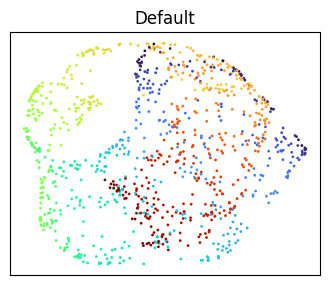

In [3]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_swiss_roll
from sklearn.preprocessing import StandardScaler

X_raw, t = make_swiss_roll(n_samples=1000, random_state=0)
X = StandardScaler().fit_transform(X_raw).astype(np.float32)


def plot_embedding(emb: np.ndarray, title: str) -> None:
    fig, ax = plt.subplots(figsize=(4, 4))
    ax.scatter(emb[:, 0], emb[:, 1], c=t, cmap="turbo", s=4, linewidths=0)
    ax.set(title=title, xticks=[], yticks=[])
    ax.set_aspect("equal")
    plt.show()


def plot_against_default(emb: np.ndarray, title: str) -> None:
    fig, axes = plt.subplots(1, 2, figsize=(8, 3.6), constrained_layout=True)
    for ax, e, ttl in zip(axes, [emb_default, emb], ["Default", title]):
        ax.scatter(e[:, 0], e[:, 1], c=t, cmap="turbo", s=4, linewidths=0)
        ax.set(title=ttl, xticks=[], yticks=[])
        ax.set_aspect("equal")
    plt.show()


emb_default = GlassBoxUMAP(random_state=0, quiet=True).fit_transform(X)
plot_embedding(emb_default, "Default")

The defaults produce an embedding that's recognizably swiss-roll-like but folded back on itself rather than fully unrolled. We'll work through several attempts at coaxing it flatter, starting with the natural single-knob first reaches and ending with the combination that actually works.

### Single-knob attempts

A higher learning rate is the most obvious thing to try. Raise `lr` two orders of magnitude, from `1e-3` to `1e-1`.

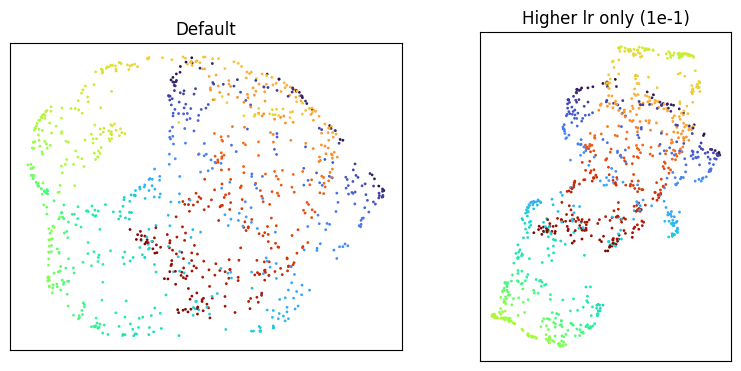

In [4]:
plot_against_default(
    GlassBoxUMAP(lr=1e-1, random_state=0, quiet=True).fit_transform(X),
    "Higher lr only (1e-1)",
)

Smaller batch size is another natural reach: more SGD steps per epoch, with more stochastic noise in each.

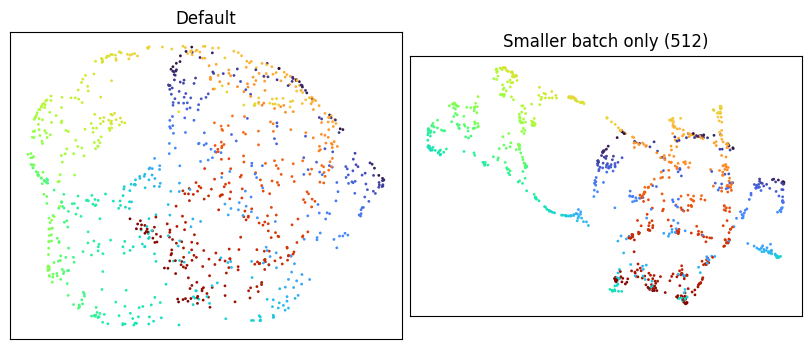

In [5]:
plot_against_default(
    GlassBoxUMAP(batch_size=512, random_state=0, quiet=True).fit_transform(X),
    "Smaller batch only (512)",
)

Reducing the encoder's capacity is the third lever. Drop the default encoder from three hidden layers of 128 units to a single hidden layer of 64.

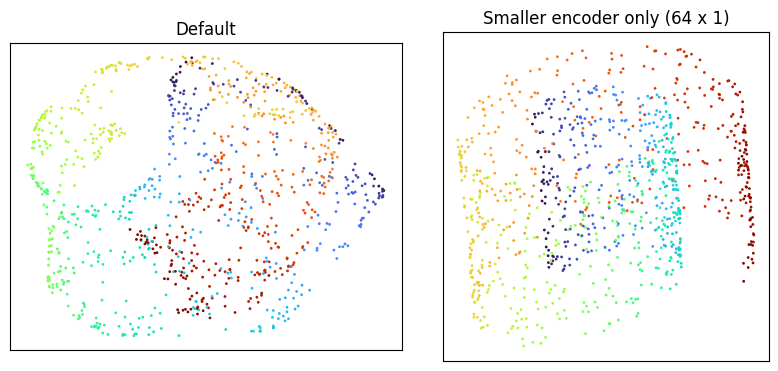

In [6]:
plot_against_default(
    GlassBoxUMAP(
        encoder_kwargs={"hidden_size": 64, "n_hidden_layers": 1},
        random_state=0,
        quiet=True,
    ).fit_transform(X),
    "Smaller encoder only (64 x 1)",
)

Each of the three by itself leaves the embedding folded. Pairing any two of them is also not enough: below is one such pair, higher learning rate plus smaller batch, with the encoder left at its default.

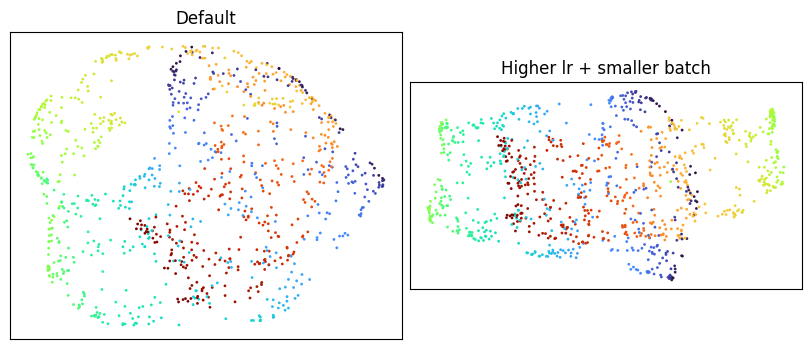

In [7]:
plot_against_default(
    GlassBoxUMAP(lr=1e-1, batch_size=512, random_state=0, quiet=True).fit_transform(X),
    "Higher lr + smaller batch",
)

### Combining all three

Applying all three changes at once does unroll the manifold.

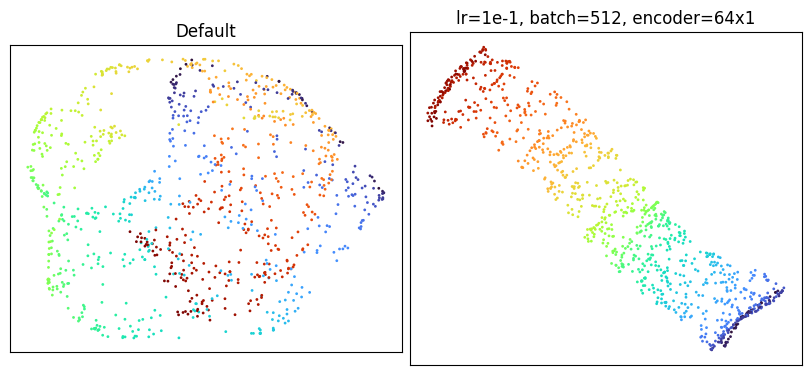

In [8]:
plot_against_default(
    GlassBoxUMAP(
        lr=1e-1,
        batch_size=512,
        encoder_kwargs={"hidden_size": 64, "n_hidden_layers": 1},
        random_state=0,
        quiet=True,
    ).fit_transform(X),
    "lr=1e-1, batch=512, encoder=64x1",
)

The manifold lays flat, with color varying smoothly from one end to the other --- better than what standard UMAP produces with its default settings (see the [Embedding Comparison](embedding_comparison.ipynb)).

## Takeaways

A few broader lessons fall out of this case study.

Glass Box UMAP can have trouble matching the manifolds that standard UMAP finds. Because the embedding has to be expressible by a neural network, the encoder's architecture is itself a constraint on the space of reachable layouts. Some manifolds that standard UMAP unrolls comfortably with default settings are not within easy reach of a default-sized encoder, no matter how long it trains.

Training a parametric model brings considerations that don't apply to standard UMAP. Standard UMAP optimizes a fixed table of point coordinates directly, so its tuning vocabulary is small. Glass Box UMAP optimizes a network's weights, which means concepts from neural network training such as encoder capacity, learning rate, batch size, and stochasticity become first-class levers. Many of the standard UMAP intuitions (increase epochs, decrease learning rate) don't transfer cleanly, and reaching for them first can be misleading.

When defaults disappoint, think about training as a whole. The Swiss roll example is a sharp illustration that the relevant parameters interact: capacity governs which layouts the encoder can express, learning rate and batch size govern which the optimizer can reach. Changing one in isolation often leaves the others as the binding constraint. When tuning, it's worth varying capacity, step size, and stochasticity together rather than sweeping a single knob and concluding "nothing helps".

## Monitoring training

The thread running through this whole page is that Glass Box UMAP is, under the hood, training a neural network. That framing matters most on large datasets, where each fit can take meaningful time and where running the kind of parameter sweep we did above is expensive. In that regime, watching training dynamics as they unfold (loss curves, intermediate embeddings) is often the fastest way to tell whether a run is heading somewhere useful or whether it's worth stopping early and changing parameters. See [Monitoring Training](monitoring_training.ipynb) for the tools Glass Box UMAP provides for that.